# Decision Tree - Classification - Quotation Data

In [5]:
# Load data
import pandas as pd

quotation_data_path = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data.xlsx"
# Date_Columns = ["Due_Date", "Date_Sent"]

# This creates: {"Due_Date": str, "Date_Sent": str}
# dtype_mapping = {col: str for col in Date_Columns}

# quotation_data_df = pd.read_excel(quotation_data_path, dtype=dtype_mapping)
quotation_data_df = pd.read_excel(quotation_data_path)
#quotation_data_df.describe()
#uotation_data_df.head(2)

In [2]:
# Lib Imports
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from joblib import dump

c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Feature Engineering
# ================================================================
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, date_col="Date", value_col="Value", estimator_col="Priced_By"):
        self.date_col = date_col
        self.value_col = value_col
        self.estimator_col = estimator_col
        
    def fit(self, X, y=None):
        # 1. Date preparation
        dates = pd.to_datetime(X[self.date_col], errors="coerce")
        self.median_date_ = dates.dropna().median()
        if pd.isna(self.median_date_):
            self.median_date_ = pd.Timestamp("2025-01-01")
            
        # 2. Value preparation
        numeric_vals = pd.to_numeric(X[self.value_col], errors="coerce")
        self.median_value_ = numeric_vals.median()
        if pd.isna(self.median_value_):
            self.median_value_ = 0.0
            
        return self
        
    def transform(self, X):
        X = X.copy()
        
        # --- 1. Date Features ---
        dates = pd.to_datetime(X[self.date_col], errors="coerce")
        X["DateMissing"] = dates.isna().astype(int)
        dates = dates.fillna(self.median_date_)
        
        X["Date_Year"] = dates.dt.year
        X["Date_Month"] = dates.dt.month
        X["Date_DayOfWeek"] = dates.dt.dayofweek
        X.drop(columns=[self.date_col], inplace=True)
        
        # --- 2. Numeric Features ---
        raw_vals = pd.to_numeric(X[self.value_col], errors="coerce")
        X[self.value_col] = np.log1p(raw_vals.fillna(self.median_value_))
        
        # --- 3. Estimator Features ---
        estimator_str = X[self.estimator_col].astype(str).str.strip().str.upper()
        
        # Vectorised clean split count (avoids slow .apply(len))
        X["EstimatorCount"] = estimator_str.str.count("/") + 1
        
        # Identify missing or placeholder values
        is_missing = (estimator_str == "MISSING") | (estimator_str == "") | (estimator_str == "NAN")
        X["EstimatorCount"] = X["EstimatorCount"].mask(is_missing, 0).astype(int)
        X["EstimatorMissing"] = is_missing.astype(int)
        
        return X


In [6]:
# Feature Lists and Data Split
# - Use TimeSeriesSplit to handle the Date_Year feature 
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing",
    # "MultipleEstimators",
    "EstimatorMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year",
    "Date_Month",
    "Date_DayOfWeek",
    "EstimatorCount"
]

categorical_features = [
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean"
]

# Raw Features ONLY
raw_features = [
    "Date", "Value", "No_Wall_Types", "Priced_By", # "Contact_Clean",
    "Suburb", "Client_Clean", "Timber_RW","RC_Pile","Steel_Beam",
    "Sheetpile","Anchor","Block", "Shotcrete","Capping_Beam","Earthwork",
    "Concrete_Slab","Precast", "Culvert","Slip_Repair","Soil_Nail",
    "Rock_RW","Bridge","Concrete", "Design_and_Build","Budget",
    "Drill_Only","Labour_Only", "Driven_Pile","Palisade","Boardwalk",
    "Soldier","Insitu", "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno", "Temp_RW","Other"
]

target = "Success"

# ================================================================
# Train Test Split
# ================================================================
# Sort the Date
quotation_data_df["Date"] = pd.to_datetime(
    quotation_data_df["Date"],
    errors="coerce"
)

quotation_data_df = (
    quotation_data_df
    .sort_values("Date")
    .reset_index(drop=True)
)

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

tscv = TimeSeriesSplit(n_splits=5)

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Training Samples : 3696
Testing Samples  : 924


In [7]:
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
    # ("scaler", StandardScaler()) dont need scaling for tree based model
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)

In [8]:
# Baseline Model
# ================================================================
decision_tree_pipeline = Pipeline([
    ("engineering", FeatureEngineer()),
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_pipeline.fit(X_train, y_train)
y_pred_baseline = decision_tree_pipeline.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Baseline Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_baseline, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

y_proba_baseline = decision_tree_pipeline.predict_proba(X_test)[:, 1]
auc_roc_baseline = roc_auc_score(y_test, y_proba_baseline)
print(f"AUC-ROC baseline: {auc_roc_baseline:.4f}")


📊 Baseline Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.83      0.92      0.87       749
  Profit (1)       0.33      0.18      0.23       175

    accuracy                           0.78       924
   macro avg       0.58      0.55      0.55       924
weighted avg       0.73      0.78      0.75       924

AUC-ROC baseline: 0.5465


In [9]:
# Hyperparameter Search - Tuning
# ================================================================
param_grid = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [2, 3, 4, 5, 6],
    "classifier__min_samples_split": [2, 5, 10, 20, 50],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20],
    "classifier__max_features": [None, "sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01]
}

random_search = RandomizedSearchCV(
    estimator=decision_tree_pipeline,
    param_distributions=param_grid,
    n_iter=150,
    cv=tscv,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
random_search.fit(X_train, y_train)

print("\nBest Parameters")
print(random_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {random_search.best_score_:.4f}")

dt_best_model_v1 = random_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = dt_best_model_v1.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

y_proba = dt_best_model_v1.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc_roc:.4f}")

# Save Trained Model
dump(dt_best_model_v1, "RandomTreeClassification_V1.joblib")
print("Model saved.")


Fitting 5 folds for each of 150 candidates, totalling 750 fits

Best Parameters
{'classifier__min_samples_split': 20, 'classifier__min_samples_leaf': 2, 'classifier__max_features': None, 'classifier__max_depth': 5, 'classifier__criterion': 'gini', 'classifier__class_weight': 'balanced', 'classifier__ccp_alpha': 0.0}

Best CV Balanced Accuracy : 0.6781

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.83      0.92      0.87       749
  Profit (1)       0.36      0.19      0.25       175

    accuracy                           0.78       924
   macro avg       0.60      0.56      0.56       924
weighted avg       0.74      0.78      0.76       924

AUC-ROC: 0.7005
Model saved.


In [79]:
# Feature Importance
feature_names = dt_best_model_v1.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_best_model_v1.named_steps[
        "classifier"
    ].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)
print(importance.head(30))

                                  Feature  Importance
2                          num__Date_Year    0.603587
953                 bin__EstimatorMissing    0.221761
0                              num__Value    0.034403
917                       bin__Steel_Beam    0.023898
946                          bin__DayWork    0.019993
118                 cat__Suburb_mahurangi    0.018838
585           cat__Client_Clean_marchcato    0.014460
918                        bin__Sheetpile    0.012573
936                      bin__Driven_Pile    0.012122
167                    cat__Suburb_pokeno    0.011369
261               cat__Client_Clean_aspec    0.009630
14                    cat__Priced_By_GARY    0.008891
492             cat__Client_Clean_higgins    0.008475
7                       cat__Priced_By_CB    0.000000
938                        bin__Boardwalk    0.000000
11                    cat__Priced_By_DEAN    0.000000
12                    cat__Priced_By_DEEP    0.000000
13                  cat__Pri


📊 Final Calibrated Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.88      0.73      0.80       749
  Profit (1)       0.33      0.56      0.41       175

    accuracy                           0.70       924
   macro avg       0.60      0.65      0.60       924
weighted avg       0.77      0.70      0.72       924

AUC-ROC Score         : 0.7343
Average Precision     : 0.4617
Raw Brier Score       : 0.1533
Calibrated Brier Score: 0.2086 (Lower is better)


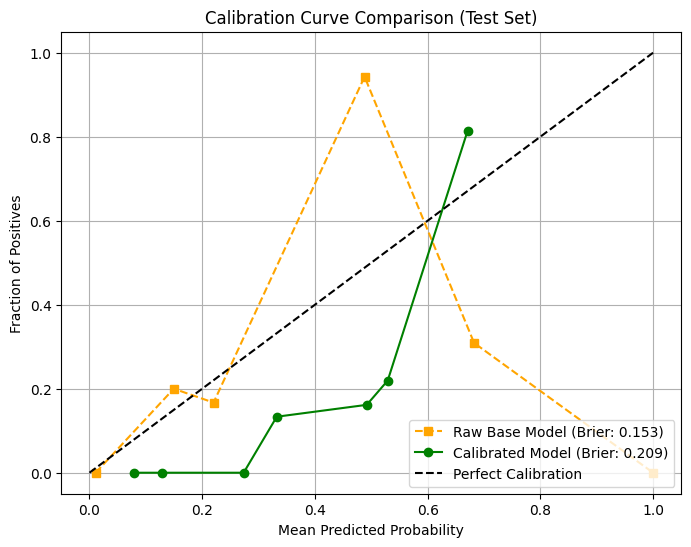

Calibrated model successfully saved.


In [80]:
# Calibration
# ===========================================================
# Step 1: Fit Calibrated Model using Out-Of-Fold Cross-Validation
# ================================================================
# Re-instantiate an un-fitted base pipeline with optimal hyper-parameters
# Extract best hyperparameters to pass into our calibrated pipeline
best_params = random_search.best_params_

unfitted_best_decision_tree_pipeline = Pipeline([
    ("engineering", FeatureEngineer()),
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        criterion=best_params["classifier__criterion"],
        max_depth=best_params["classifier__max_depth"],
        min_samples_split=best_params["classifier__min_samples_split"],
        min_samples_leaf=best_params["classifier__min_samples_leaf"],
        max_features=best_params["classifier__max_features"],
        class_weight=best_params["classifier__class_weight"],
        ccp_alpha=best_params["classifier__ccp_alpha"]
    ))
])

# CalibratedClassifierCV wraps the pipeline and uses TimeSeriesSplit out-of-fold predictions
calibrated_model = CalibratedClassifierCV(
    estimator=unfitted_best_decision_tree_pipeline,
    method="isotonic",
    cv=tscv
)

calibrated_model.fit(X_train, y_train)

# Step 2: Evaluation on Unseen Test Data
# ================================================================
# Get predictions from base (uncalibrated) best model vs. calibrated model
uncalibrated_model = random_search.best_estimator_

y_proba_raw = uncalibrated_model.predict_proba(X_test)[:, 1]
y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_cal = calibrated_model.predict(X_test)

print("\n📊 Final Calibrated Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_cal, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

brier_raw = brier_score_loss(y_test, y_proba_raw)
brier_cal = brier_score_loss(y_test, y_proba_cal)

print(f"AUC-ROC Score         : {roc_auc_score(y_test, y_proba_cal):.4f}")
print(f"Average Precision     : {average_precision_score(y_test, y_proba_cal):.4f}")
print(f"Raw Brier Score       : {brier_raw:.4f}")
print(f"Calibrated Brier Score: {brier_cal:.4f} (Lower is better)")

# ================================================================
# Step 3: Side-by-Side Calibration Comparison Plot
# ================================================================
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_proba_raw, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(mean_pred_raw, frac_pos_raw, 's--', label=f'Raw Base Model (Brier: {brier_raw:.3f})', color='orange')
plt.plot(mean_pred_cal, frac_pos_cal, 'o-', label=f'Calibrated Model (Brier: {brier_cal:.3f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve Comparison (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Save the final Calibrated Pipeline
dump(calibrated_model, "DecisionTreeClassification_Calibrated.joblib")
print("Calibrated model successfully saved.")

Generating SHAP Global Summary Plot...


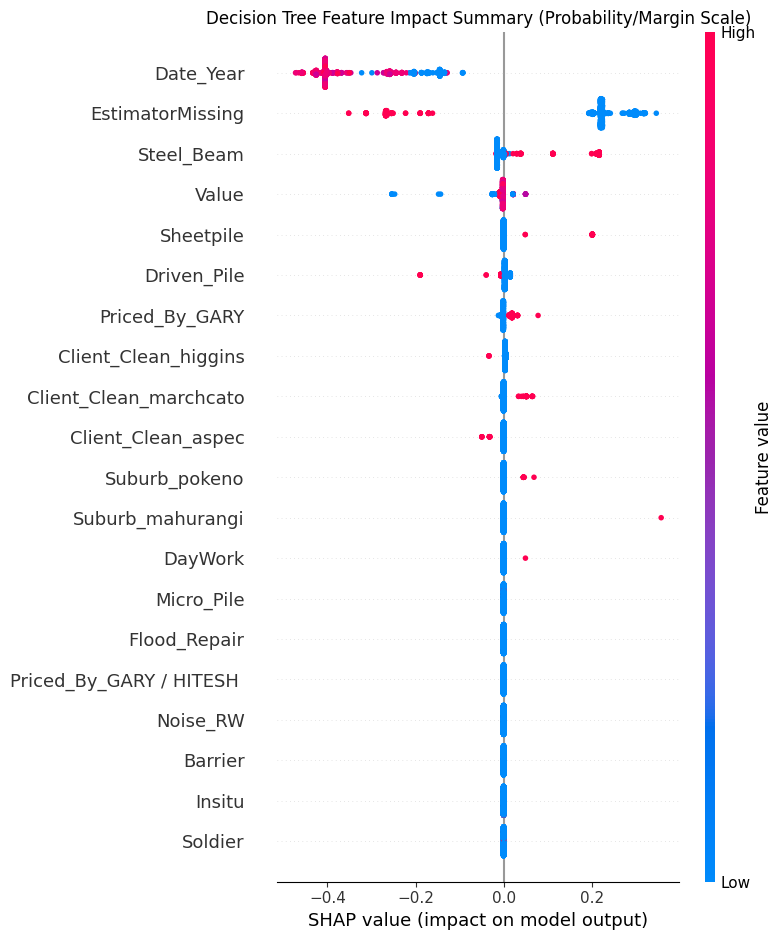


Generating Local Explanation for Test Sample #0...


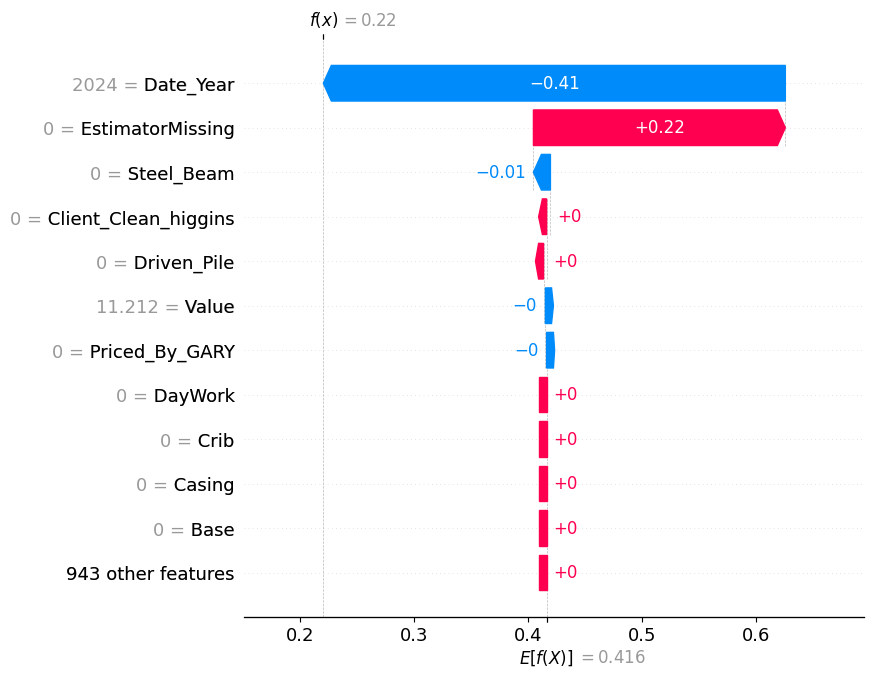

In [85]:
# SHAP for Decision Tree
# ==========================================================
import shap
import pandas as pd
import matplotlib.pyplot as plt

def analyze_decision_tree_shap(decision_tree_pipeline, X_train, X_test, top_n=20):
    """
    Computes and visualizes SHAP values for a Decision Tree Pipeline,
    dynamically handling any number of feature engineering steps.
    """
    # 1. Safely retrieve pipeline components
    classifier = decision_tree_pipeline.named_steps['classifier']       
    preprocessor = decision_tree_pipeline.named_steps['preprocessor']   
    
    # 2. Sequentially pass data through all transformers before 'preprocessor'
    X_train_curr = X_train.copy()
    X_test_curr = X_test.copy()

    for step_name, step_obj in decision_tree_pipeline.steps:
        if step_name == 'preprocessor':
            break
        X_train_curr = step_obj.transform(X_train_curr)
        X_test_curr = step_obj.transform(X_test_curr)

    # 3. Pass through ColumnTransformer
    X_train_trans = preprocessor.transform(X_train_curr)
    X_test_trans = preprocessor.transform(X_test_curr)

    # 4. Extract feature names post-ColumnTransformer
    feature_names = []
    for name, trans, cols in preprocessor.transformers_:
        if name == 'num':
            feature_names.extend(cols)
        elif name == 'cat':
            ohe = trans.named_steps['encoder']
            cat_cols = ohe.get_feature_names_out(cols).tolist()
            feature_names.extend(cat_cols)
        elif name in ['bin', 'cycle']:
            feature_names.extend(cols)

    # Convert test array back to DataFrame for cleaner SHAP displays
    X_test_df = pd.DataFrame(X_test_trans, columns=feature_names)
    X_train_df = pd.DataFrame(X_train_trans, columns=feature_names)

    # 5. Initialize TreeExplainer (CRITICAL FIX)
    # TreeExplainer calculates SHAP by routing data through the tree's branches.
    # We do not strictly need X_train_df for TreeExplainer unless we want 
    # interventional feature perturbation, but standard path-dependent SHAP is fine.
    explainer = shap.TreeExplainer(classifier, X_train_df)
    
    # Generate SHAP values for the test set
    shap_values_raw = explainer(X_test_df)
    
    # 6. Slice for the Positive Class (CRITICAL FIX)
    # Scikit-learn trees return SHAP values for [Class_0, Class_1]. 
    # We slice [:, :, 1] to only look at the impacts driving a "Win/Profit" (Class 1).
    shap_values_pos = shap_values_raw[:, :, 1]

    # 7. Global Summary Plot (Beeswarm Plot)
    print("Generating SHAP Global Summary Plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_pos, X_test_df, max_display=top_n, show=False)
    plt.title("Decision Tree Feature Impact Summary (Probability/Margin Scale)", fontsize=12)
    plt.tight_layout()
    plt.show()

    # 8. Single Quote Local Interpretation (Waterfall Plot)
    print("\nGenerating Local Explanation for Test Sample #0...")
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values_pos[0], max_display=12)

    return explainer, shap_values_pos, X_test_df

# Execute function
explainer, shap_values, X_test_trans_df = analyze_decision_tree_shap(dt_best_model_v1, X_train, X_test)